# GPROF V07

This notebook evaluatrs GPROF V07 retrievals for GMI and ATMS using the SatRain dataset.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from typing import Tuple

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

## Helper functions

In [2]:
def get_granule(path: Path) -> int:
    """
    Extract granule number from GPROF file name.

    Args:
        path: A Path object pointing to a GPROF L2A file.

    Return:
        The granule number as an integer.
    """
    # GPROF filename example: 2A.GPM.GMI.GPROF2021v1.20200630-S225114-E002346.036018.V07A.HDF5
    path = Path(path)
    parts = path.name.split('.')
    granule = int(parts[-3])
    return granule

GPROF_DATA_PATH = "/pdata4/archive/GPM/2A-CLIM_ATMS_V7//"
gprof_files = Path(GPROF_DATA_PATH).glob("*.HDF5")
gprof_files = {
    get_granule(path): path for path in gprof_files
}

In [3]:
def load_gprof_precip(path: Path, scan_start: int, scan_end: int) -> xr.Dataset:
    """
    Load GPROF precipitation.

    Args:
        path: A Path object pointing to the IMERG file to load.
        scan_start: The start scan of the collocation.
        scan_end: Index pointing to the first scan that is not part of 
             the collocation anymore.

    Return:
        An xarray.Dataset containing the 'surface_precip', 'probability_of_precip',
        'precipitation_flag', 'probability_of_heavy_precip', and 'heavy_precip_flag'
        extracted from the GPROF file pointed to by 'path'.
    """
    slc = slice(scan_start, scan_end)
    with h5py.File(path) as data:
        lons = data["S1/Latitude"][slc]
        lats = data["S1/Longitude"][slc]
        
        surface_precip = data["S1/surfacePrecipitation"][slc]
        invalid = surface_precip < 0
        surface_precip[invalid] = np.nan
        probability_of_precip = data["S1/probabilityOfPrecip"][slc] / 100.0
        precipitation_flag = data["S1/precipitationYesNoFlag"][slc]
        probability_of_heavy_precip = np.clip(surface_precip / 100, 0.0, 1.0)

    data.close()
    del data
        
    return xr.Dataset({
        "longitude": (("scan", "pixel"), lons),
        "latitude": (("scan", "pixel"), lats),
        "surface_precip": (("scan", "pixel"), surface_precip),
        "probability_of_precip": (("scan", "pixel"), probability_of_precip),
        "precip_flag": (("scan", "pixel"), precipitation_flag),
        "heavy_precip_flag": (("scan", "pixel"), 10 < surface_precip),
    })


In [4]:
from typing import List, Union
class GPROFRetrieval:
    """
    Callable implementing the GPROF V07 retrieval for evaluation on the SatRain benchmark dataset.
    """
    def __init__(
        self,
        data_paths: Union[List[Path], str, Path]
    ):
        if isinstance(data_paths, (str, Path)):
            data_paths = [Path(data_paths)]
        gprof_files = sum([list(Path(path).glob("**/*.HDF5")) for path in data_paths], [])
        self.gprof_files = {
            get_granule(path): path for path in gprof_files
        }

    def __call__(self, input_data: xr.Dataset) -> xr.Dataset:
        """
        Args:
            input_data: An xarray.Dataset containing the GMI input data.
    
        Return:
            An xarray.Dataset containing the retrieval results.
        """
        input_file = input_data.attrs["gpm_input_file"]
        scan_start = input_data.attrs["scan_start"]
        scan_end = input_data.attrs["scan_end"]
        granule = get_granule(input_file)
        path = self.gprof_files[granule]
        return load_gprof_precip(path, scan_start, scan_end)

In [5]:
gmi_retrieval = GPROFRetrieval("/pdata4/archive/GPM/2A-CLIM_GMI/")
atms_retrieval = GPROFRetrieval([
    "/data/simon/satellite_data/gpm/2a/noaa20/",
    "/edata1/simon/satellite_data/gpm/2a/noaa20/",
    "/edata2/simon/satellite_data/gpm/2a/noaa20/"
] )
len(atms_retrieval.gprof_files)

7462

In [6]:
len(atms_retrieval.gprof_files)

7462

## Case study

To verify the implementation of the ``retrieval_fn`` callback, we display the results for a single scene using the evaluator's ``plot_retrieval_results`` function.

In [10]:
from satrain.target import TargetConfig
from satrain.evaluation import Evaluator

target_config = TargetConfig(min_rqi=0.5)
evaluator = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="on_swath",
    retrieval_input=["gmi"],
    download=True,
    target_config=target_config,
)

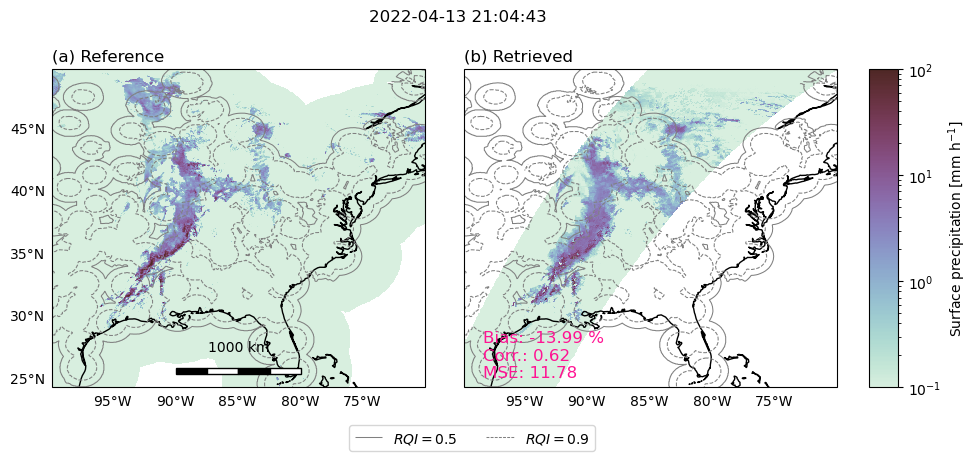

In [12]:
fig = evaluator.plot_retrieval_results(811, gmi_retrieval, include_metrics=True)

In [13]:
retrievals = {
    "gmi": gmi_retrieval,
    "atms": atms_retrieval
}

In [14]:
import logging
LOGGER = logging.getLogger("evaluation")
    
results = []
domains = ["austria", "conus", "korea"]
base_sensors = ["atms", "gmi"]

for sensor in base_sensors:
    for domain in domains:
        LOGGER.info("Running evaluation for domain '%s'.", domain)
        evaluator = Evaluator(
            domain=domain,
            base_sensor=sensor,
            geometry="on_swath",
            retrieval_input=[sensor],
            download=True,
            target_config=target_config,
        )
        evaluator.evaluate(
            retrievals[sensor],
            n_processes=16
        )
        res = evaluator.get_results()
        results.append(res)
        res.to_netcdf(f"gprof_v07_{sensor}_{domain}.nc")

INFO     Running evaluation for domain 'austria'.

Output()

ERROR    Encountered an error when processing scene 34.                                                            
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_1849378/972999236.py", line 30, in __call__                                        
             return load_gprof_precip(path, scan_start, scan_end)                                                  
           File "/tmp/ipykernel_1849378/767458603.py", line 17, in load_gprof_precip                               
             with h5py.File(path) as data:                                                                         
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/h5py/_hl/files.py", line 562, in  
         __init__                                                                                                  
             fid = make_fid(name, mode, userblock_size, fapl, fcpl, swmr=swmr)                                     
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/h5py/_hl/files.py", line 235, in  
         make_fid                                                                                                  
             fid = h5f.open(name, flags, fapl=fapl)                                                                
           File "h5py/_objects.pyx", line 54, in h5py._objects.with_phil.wrapper                                   
           File "h5py/_objects.pyx", line 55, in h5py._objects.with_phil.wrapper                                   
           File "h5py/h5f.pyx", line 102, in h5py.h5f.open                                                         
         OSError: Unable to synchronously open file (truncated file: eof = 7269120, sblock->base_addr = 0,         
         stored_eof = 7943823)                                                                                     
         """                                                                                                       
                                                                                                                   
         The above exception was the direct cause of the

ERROR    Encountered an error when processing scene 80.                                                            
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_1849378/972999236.py", line 30, in __call__                                        
             return load_gprof_precip(path, scan_start, scan_end)                                                  
           File "/tmp/ipykernel_1849378/767458603.py", line 17, in load_gprof_precip                               
             with h5py.File(path) as data:                                                                         
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/h5py/_hl/files.py", line 562, in  
         __init__                                                                                                  
             fid = make_fid(name, mode, userblock_size, fapl, fcpl, swmr=swmr)                                     
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/h5py/_hl/files.py", line 235, in  
         make_fid                                                                                                  
             fid = h5f.open(name, flags, fapl=fapl)                                                                
           File "h5py/_objects.pyx", line 54, in h5py._objects.with_phil.wrapper                                   
           File "h5py/_objects.pyx", line 55, in h5py._objects.with_phil.wrapper                                   
           File "h5py/h5f.pyx", line 102, in h5py.h5f.open                                                         
         OSError: Unable to synchronously open file (truncated file: eof = 4541952, sblock->base_addr = 0,         
         stored_eof = 8217904)                                                                                     
         """                                                                                                       
                                                                                                                   
         The above exception was the direct cause of the

ERROR    Encountered an error when processing scene 421.                                                           
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_1849378/972999236.py", line 30, in __call__                                        
             return load_gprof_precip(path, scan_start, scan_end)                                                  
           File "/tmp/ipykernel_1849378/767458603.py", line 17, in load_gprof_precip                               
             with h5py.File(path) as data:                                                                         
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/h5py/_hl/files.py", line 562, in  
         __init__                                                                                                  
             fid = make_fid(name, mode, userblock_size, fapl, fcpl, swmr=swmr)                                     
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/h5py/_hl/files.py", line 235, in  
         make_fid                                                                                                  
             fid = h5f.open(name, flags, fapl=fapl)                                                                
           File "h5py/_objects.pyx", line 54, in h5py._objects.with_phil.wrapper                                   
           File "h5py/_objects.pyx", line 55, in h5py._objects.with_phil.wrapper                                   
           File "h5py/h5f.pyx", line 102, in h5py.h5f.open                                                         
         OSError: Unable to synchronously open file (truncated file: eof = 5415808, sblock->base_addr = 0,         
         stored_eof = 8024825)                                                                                     
         """                                                                                                       
                                                                                                                   
         The above exception was the direct cause of the

...

ERROR    Encountered an error when processing scene 2420.                                                          
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_1849378/972999236.py", line 29, in __call__                                        
             path = self.gprof_files[granule]                                                                      
         KeyError: 49287                                                                                           
         """                                                                                                       
                                                                                                                   
         The above exception was the direct cause of the following exception:                                      
                                                                                                                   
         Traceback (most recent call last):                                                                        
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1324, in evaluate                        
             task.result()                                                                                         
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/_base.py", line 451, in      
         result                                                                                                    
             return self.__get_result()                                                                            
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/_base.py", line 403, in      
         __get_result                                                                                              
             raise self._exception                                                                                 
         KeyError: 49287

INFO     Running evaluation for domain 'korea'.

Output()

ERROR    Encountered an error when processing scene 51.                                                            
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_1849378/972999236.py", line 29, in __call__                                        
             path = self.gprof_files[granule]                                                                      
         KeyError: 49276                                                                                           
         """                                                                                                       
                                                                                                                   
         The above exception was the direct cause of the following exception:                                      
                                                                                                                   
         Traceback (most recent call last):                                                                        
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1324, in evaluate                        
             task.result()                                                                                         
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/_base.py", line 451, in      
         result                                                                                                    
             return self.__get_result()                                                                            
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/_base.py", line 403, in      
         __get_result                                                                                              
             raise self._exception                                                                                 
         KeyError: 49276

ERROR    Encountered an error when processing scene 52.                                                            
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_1849378/972999236.py", line 29, in __call__                                        
             path = self.gprof_files[granule]                                                                      
         KeyError: 49286                                                                                           
         """                                                                                                       
                                                                                                                   
         The above exception was the direct cause of the following exception:                                      
                                                                                                                   
         Traceback (most recent call last):                                                                        
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1324, in evaluate                        
             task.result()                                                                                         
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/_base.py", line 451, in      
         result                                                                                                    
             return self.__get_result()                                                                            
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/_base.py", line 403, in      
         __get_result                                                                                              
             raise self._exception                                                                                 
         KeyError: 49286